In [1]:
from pathlib import Path
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [3]:
safe_2021 = Path(
    r"../data\raw\day_24\S2B_MSIL2A_20210309T050649_N0500_R019_T43QHV_20230524T160017.SAFE"
)

safe_2026 = Path(
    r"../data/raw/day_04/S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE"
)

output_dir = Path("../data/processed")
output_dir.mkdir(exist_ok=True)

In [4]:
def find_band(safe_path, band_name):
    
    img_dir = list(
        safe_path.glob(
            "GRANULE/*/IMG_DATA/R10m"
        )
    )[0]

    matches = list(
        img_dir.glob(f"*_{band_name}_10m.jp2")
    )

    return matches[0]

In [5]:
bands = ["B02", "B03", "B04", "B08"]

paths_2021 = {}
paths_2026 = {}

for band in bands:
    paths_2021[band] = find_band(
        safe_2021,
        band
    )

    paths_2026[band] = find_band(
        safe_2026,
        band
    )

In [6]:
for b in bands:
    print("\n", b)

    print("2021:", paths_2021[b])
    print("2026:", paths_2026[b])


 B02
2021: ..\data\raw\day_24\S2B_MSIL2A_20210309T050649_N0500_R019_T43QHV_20230524T160017.SAFE\GRANULE\L2A_T43QHV_A020923_20210309T051857\IMG_DATA\R10m\T43QHV_20210309T050649_B02_10m.jp2
2026: ..\data\raw\day_04\S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE\GRANULE\L2A_T43QHV_A048236_20260601T051356\IMG_DATA\R10m\T43QHV_20260601T050649_B02_10m.jp2

 B03
2021: ..\data\raw\day_24\S2B_MSIL2A_20210309T050649_N0500_R019_T43QHV_20230524T160017.SAFE\GRANULE\L2A_T43QHV_A020923_20210309T051857\IMG_DATA\R10m\T43QHV_20210309T050649_B03_10m.jp2
2026: ..\data\raw\day_04\S2B_MSIL2A_20260601T050649_N0512_R019_T43QHV_20260601T085256.SAFE\GRANULE\L2A_T43QHV_A048236_20260601T051356\IMG_DATA\R10m\T43QHV_20260601T050649_B03_10m.jp2

 B04
2021: ..\data\raw\day_24\S2B_MSIL2A_20210309T050649_N0500_R019_T43QHV_20230524T160017.SAFE\GRANULE\L2A_T43QHV_A020923_20210309T051857\IMG_DATA\R10m\T43QHV_20210309T050649_B04_10m.jp2
2026: ..\data\raw\day_04\S2B_MSIL2A_20260601T050649_N0512_R019_T43Q

In [7]:
def read_band(path):

    with rasterio.open(path) as src:
        return src.read(1)

In [8]:
r21 = read_band(paths_2021["B04"])
g21 = read_band(paths_2021["B03"])
b21 = read_band(paths_2021["B02"])

r26 = read_band(paths_2026["B04"])
g26 = read_band(paths_2026["B03"])
b26 = read_band(paths_2026["B02"])

In [9]:
def create_rgb(r, g, b):

    rgb = np.dstack([r, g, b])

    rgb = rgb.astype(np.float32)

    p2 = np.percentile(rgb, 2)
    p98 = np.percentile(rgb, 98)

    rgb = np.clip(rgb, p2, p98)

    rgb = (rgb - p2) / (p98 - p2)

    return rgb

In [10]:
rgb21 = create_rgb(r21, g21, b21)
rgb26 = create_rgb(r26, g26, b26)

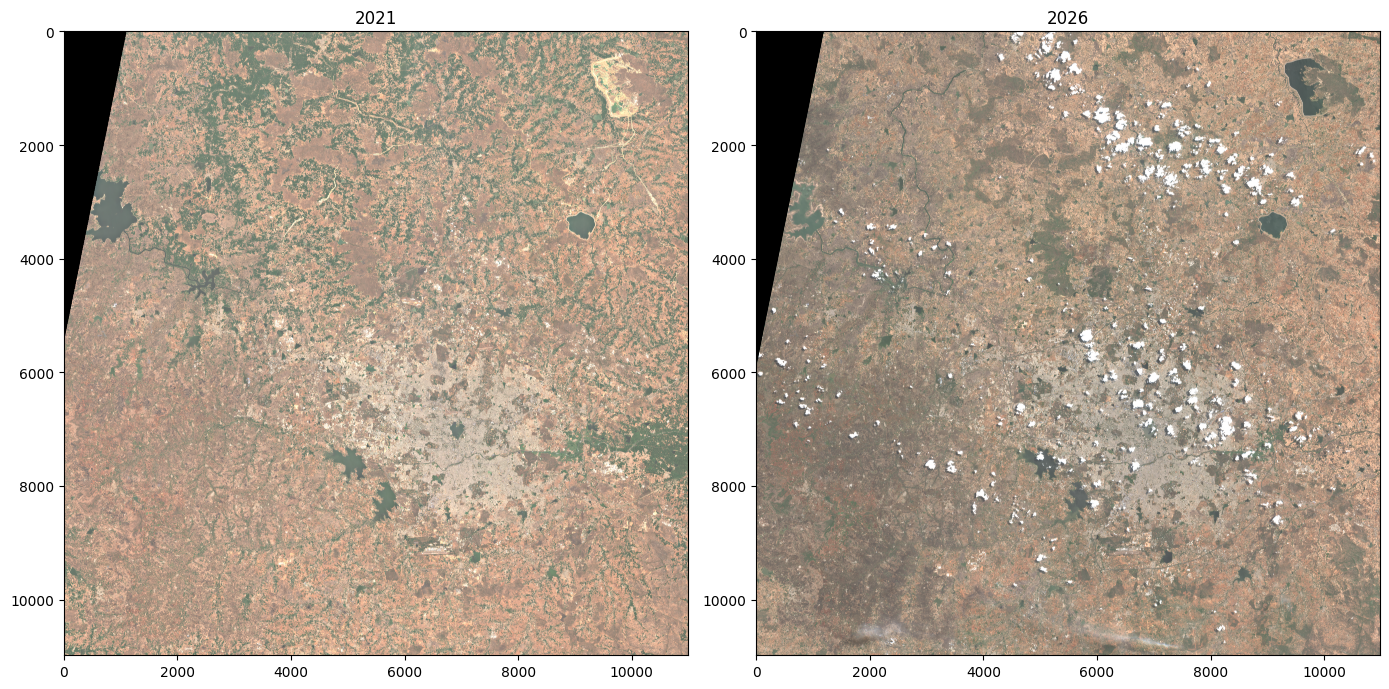

In [11]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(14, 7)
)

ax[0].imshow(rgb21)
ax[0].set_title("2021")

ax[1].imshow(rgb26)
ax[1].set_title("2026")

plt.tight_layout()
plt.show()

In [12]:
plt.imsave(
    "../data/processed/rgb_2021.png",
    rgb21
)

plt.imsave(
    "../data/processed/rgb_2026.png",
    rgb26
)